# Procesamiento visual controlado con OpenCV

## Objetivo y recorrido

En este notebook se estudia cómo una imagen pasa de ser una fotografía en color a representaciones útiles para tareas de visión por computador. Se comparan cambios de espacio de color, reducción de tamaño, selección de una región de interés, suavizado, umbralización y detección de bordes

Cada transformación se evalúa según la información que conserva o descarta y según su utilidad para una tarea concreta: obtener una máscara de segmentación del bordado de la perrita

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

OpenCV: 5.0.0
NumPy: 2.4.6


## Lectura de la imagen con OpenCV


In [2]:
imagen_original = cv2.imread("data/lupe_navidad.jpg")

if imagen_original is None:
    raise FileNotFoundError("No se pudo cargar la imagen")

imagen = imagen_original.copy()

print("Original:", imagen_original.shape)
print("Copia:", imagen.shape)

Original: (2858, 2252, 3)
Copia: (2858, 2252, 3)


La imagen se carga con `cv2.imread` que devuelve los canales en orden BGR. Se conserva una copia de trabajo para que las transformaciones posteriores no modifiquen la entrada original. La forma impresa permite comprobar desde el principio el alto, el ancho y el número de canales disponibles

## Inspección inicial de la imagen

In [3]:
print("Shape:", imagen.shape)
print("dtype:", imagen.dtype)
print("Mínimo:", imagen.min())
print("Máximo:", imagen.max())
print("Memoria:", imagen.nbytes, "bytes")

Shape: (2858, 2252, 3)
dtype: uint8
Mínimo: 0
Máximo: 255
Memoria: 19308648 bytes


In [4]:
alto, ancho, canales = imagen.shape

print("Alto:", alto)
print("Ancho:", ancho)
print("Canales:", canales)

Alto: 2858
Ancho: 2252
Canales: 3


Los valores permiten verificar el tipo de objeto que se manipula.

`uint8` representa intensidades entre 0 y 255 y una imagen en color ocupa tres matrices asociadas a sus canales. La memoria calculada es útil para anticipar el coste de mantener varias versiones de la imagen durante el procesamiento

## Espacios de color

In [5]:
imagen_rgb = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB)

In [6]:
imagen_gray = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2GRAY)
imagen_hsv = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2HSV)

In [7]:
print("BGR:", imagen_original.shape)
print("RGB:", imagen_rgb.shape)
print("Gray:", imagen_gray.shape)
print("HSV:", imagen_hsv.shape)

BGR: (2858, 2252, 3)
RGB: (2858, 2252, 3)
Gray: (2858, 2252)
HSV: (2858, 2252, 3)


La conversión no cambia el número de píxeles de la imagen RGB, pero sí cambia la interpretación de sus canales. La imagen en gris conserva una sola intensidad por píxel, mientras que HSV mantiene tres componentes con una organización sobre color, saturación y brillo

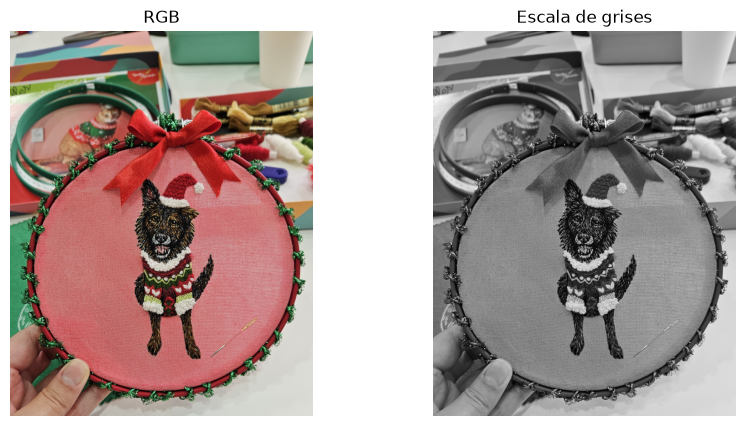

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(imagen_rgb)
ax[0].set_title("RGB")

ax[1].imshow(imagen_gray, cmap="gray")
ax[1].set_title("Escala de grises")

for a in ax:
    a.axis("off")

plt.show()

In [9]:
h, s, v = cv2.split(imagen_hsv)

print("H:", h.min(), h.max())
print("S:", s.min(), s.max())
print("V:", v.min(), v.max())

H: 0 179
S: 0 255
V: 0 255


BGR → RGB reorganiza canales. BGR → Gray reduce la representación a una intensidad. BGR → HSV transforma la manera de describir el color.

Esto último puede ser especialmente útil cuando una tarea depende del color: HSV permite separar aproximadamente el tipo de color de su saturación y luminosidad.

## Redimensionamiento e interpolación

In [10]:
nuevo_ancho = 400
escala = nuevo_ancho / imagen_rgb.shape[1]
nuevo_alto = int(imagen_rgb.shape[0] * escala)
dimensiones = (nuevo_ancho, nuevo_alto)

In [11]:
resize_nearest = cv2.resize(imagen_rgb, dimensiones, interpolation=cv2.INTER_NEAREST)
resize_linear = cv2.resize(imagen_rgb, dimensiones, interpolation=cv2.INTER_LINEAR)
resize_area = cv2.resize(imagen_rgb, dimensiones, interpolation=cv2.INTER_AREA)

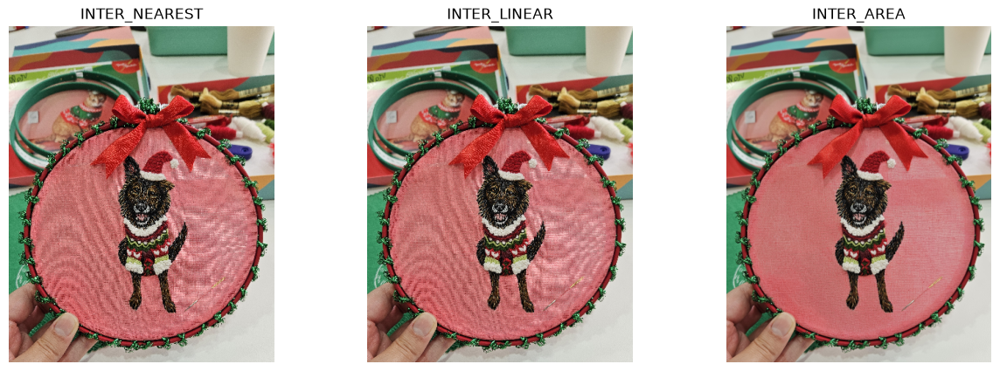

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(resize_nearest)
ax[0].set_title("INTER_NEAREST")

ax[1].imshow(resize_linear)
ax[1].set_title("INTER_LINEAR")

ax[2].imshow(resize_area)
ax[2].set_title("INTER_AREA")

for a in ax:
    a.axis("off")

plt.show()

La comparación visual permite observar el coste de reducir de tamaño:
- `INTER_NEAREST` conserva bloques y cambios abruptos
- `INTER_LINEAR` produce una transición un poco más suave
- `INTER_AREA` tiende a preservar mejor la apariencia global al reducir

Al reducir una imagen hay que decidir cómo representar muchos píxeles originales mediante menos píxeles. La interpolación define cómo se calculan esos nuevos valores.

INTER_NEAREST prioriza el valor del vecino más próximo y puede generar resultados más abruptos. INTER_LINEAR interpola utilizando píxeles cercanos. INTER_AREA suele ser una opción apropiada para reducción porque considera la relación entre áreas de píxeles.

## Región de interés — ROI

In [13]:
x1 = 876
y1 = 1000
x2 = 1546
y2 = 2486

roi = imagen_rgb[y1:y2, x1:x2]

In [14]:
print("Original:", imagen_rgb.shape)
print("ROI:", roi.shape)

Original: (2858, 2252, 3)
ROI: (1486, 670, 3)


La ROI reduce el problema a la zona que contiene el objeto de interés. Además de ahorrar memoria y tiempo de cómputo, evita que el fondo del taller domine una segmentación calculada sobre toda la fotografía

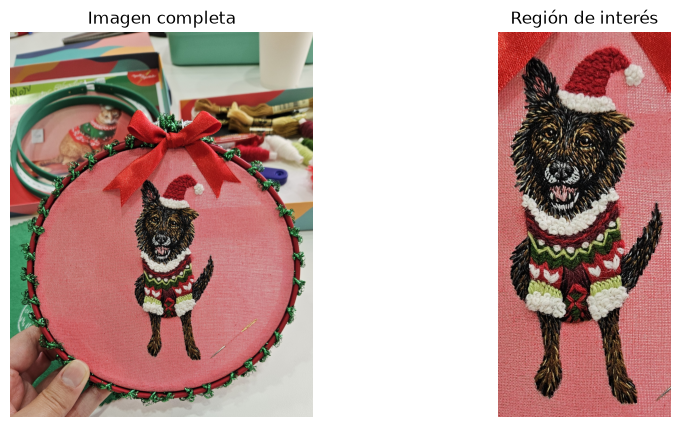

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(imagen_rgb)
ax[0].set_title("Imagen completa")

ax[1].imshow(roi)
ax[1].set_title("Región de interés")

for a in ax:
    a.axis("off")

plt.show()

## Suavizado y reducción de variaciones locales

In [16]:
blur_3 = cv2.GaussianBlur(imagen_rgb, (3, 3), 0)
blur_7 = cv2.GaussianBlur(imagen_rgb, (7, 7), 0)
blur_15 = cv2.GaussianBlur(imagen_rgb, (15, 15), 0)

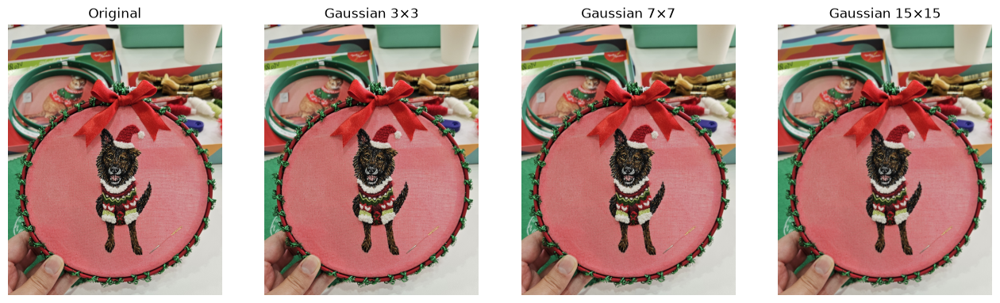

In [17]:
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

imagenes = [imagen_rgb, blur_3, blur_7, blur_15]

titulos = [
    "Original",
    "Gaussian 3×3",
    "Gaussian 7×7",
    "Gaussian 15×15"
]

for a, img, titulo in zip(ax, imagenes, titulos):
    a.imshow(img)
    a.set_title(titulo)
    a.axis("off")

plt.show()

El filtro gaussiano reemplaza cada píxel teniendo en cuenta su vecindario mediante una ponderación gaussiana. Un kernel mayor incorpora información de una región más amplia y genera un suavizado más fuerte.

El suavizado puede reducir ruido, pero también elimina detalles y debilita bordes. Por eso no existe un kernel universalmente “mejor”.

## Comparación de filtros

In [18]:
gaussiano = cv2.GaussianBlur(imagen_rgb, (7, 7), 0)
promedio = cv2.blur(imagen_rgb, (7, 7))
mediana = cv2.medianBlur(imagen_rgb, 7)

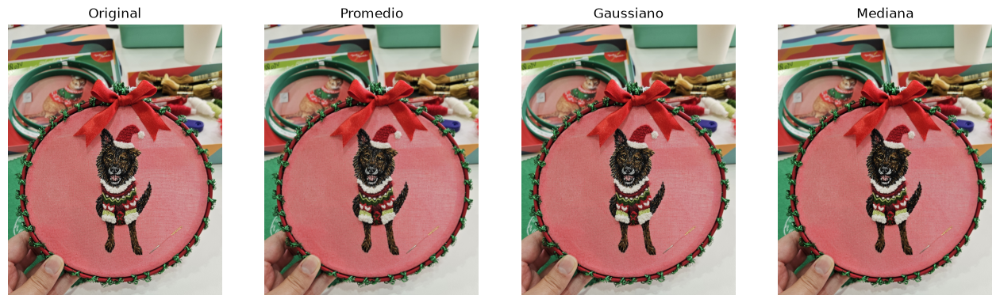

In [19]:
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

imagenes = [
    imagen_rgb,
    promedio,
    gaussiano,
    mediana
]

titulos = [
    "Original",
    "Promedio",
    "Gaussiano",
    "Mediana"
]

for a, img, titulo in zip(ax, imagenes, titulos):
    a.imshow(img)
    a.set_title(titulo)
    a.axis("off")

plt.show()

Acá la diferencia no es muy significativa. El promedio tiende a suavizar de forma uniforme, el gaussiano conserva una transición más gradual y la mediana suele ser más resistente a valores aislados extremos

Un filtro promedio sustituye valores utilizando un promedio uniforme del vecindario. El gaussiano da diferente importancia a los píxeles según su distancia. El filtro de mediana selecciona la mediana del vecindario y tiene un comportamiento diferente frente a valores extremos

## Umbralización global

In [20]:
gris = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2GRAY)

In [21]:
_, umbral_80 = cv2.threshold(gris, 80, 255, cv2.THRESH_BINARY)
_, umbral_130 = cv2.threshold(gris, 130, 255, cv2.THRESH_BINARY)
_, umbral_180 = cv2.threshold(gris, 180, 255, cv2.THRESH_BINARY)

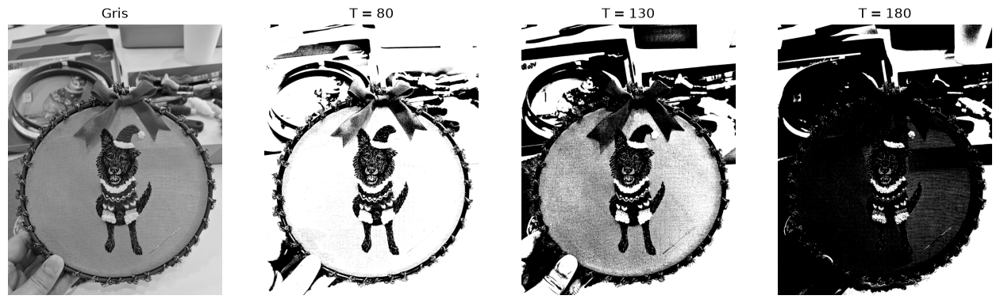

In [22]:
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

imagenes = [
    gris,
    umbral_80,
    umbral_130,
    umbral_180
]

titulos = [
    "Gris",
    "T = 80",
    "T = 130",
    "T = 180"
]

for a, img, titulo in zip(ax, imagenes, titulos):
    a.imshow(img, cmap="gray")
    a.set_title(titulo)
    a.axis("off")

plt.show()

Los tres resultados muestran cómo el umbral controla el equilibrio entre regiones claras y oscuras. Un valor bajo clasifica más píxeles como blancos, uno alto exige mayor intensidad y produce una máscara más restrictiva

Una umbralización binaria aplica esencialmente una regla:

$$I(x,y)>T \Rightarrow 255$$

$$I(x,y)\leq T \Rightarrow 0$$

Esto simplifica radicalmente la imagen. Se pierde la intensidad original y se conserva solamente la clasificación de cada píxel respecto al umbral.

## Umbralización automática con Otsu

In [23]:
valor_otsu, umbral_otsu = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Umbral elegido por Otsu:", valor_otsu)

Umbral elegido por Otsu: 114.0


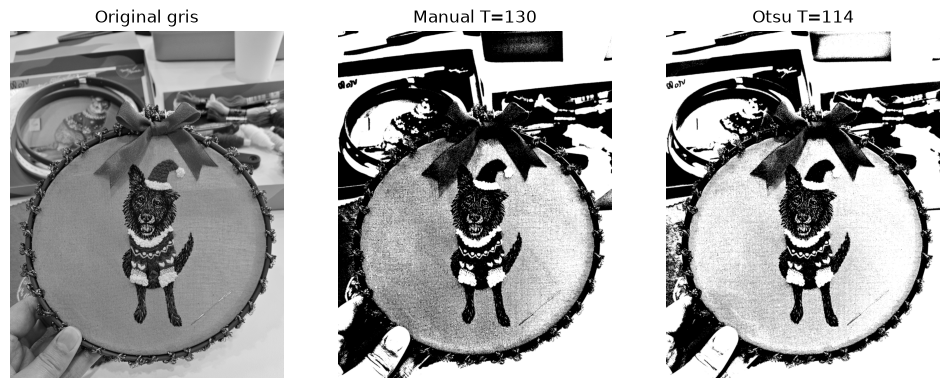

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

ax[0].imshow(gris, cmap="gray")
ax[0].set_title("Original gris")

ax[1].imshow(umbral_130, cmap="gray")
ax[1].set_title("Manual T=130")

ax[2].imshow(umbral_otsu, cmap="gray")
ax[2].set_title(f"Otsu T={valor_otsu:.0f}")

for a in ax:
    a.axis("off")

plt.show()

Aquí se contrasta una decisión manual (`T=130`) con la decisión automática de Otsu

Otsu busca automáticamente un umbral que separe las intensidades en dos grupos según un criterio estadístico de varianza. Funciona especialmente bien cuando la distribución permite distinguir razonablemente dos clases

Automático no significa correcto porque si la iluminación, el fondo y el objeto no forman grupos adecuados, Otsu puede no corresponder a la segmentación necesaria

## Umbralización adaptativa

In [25]:
gris_suave = cv2.GaussianBlur(imagen_gray, (5, 5), 0)

In [27]:
umbral_adaptativo = cv2.adaptiveThreshold(gris_suave, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

In [28]:
block_size = 11
C = 2

print("Tamaño del vecindario:", block_size)
print("Constante C:", C)

Tamaño del vecindario: 11
Constante C: 2


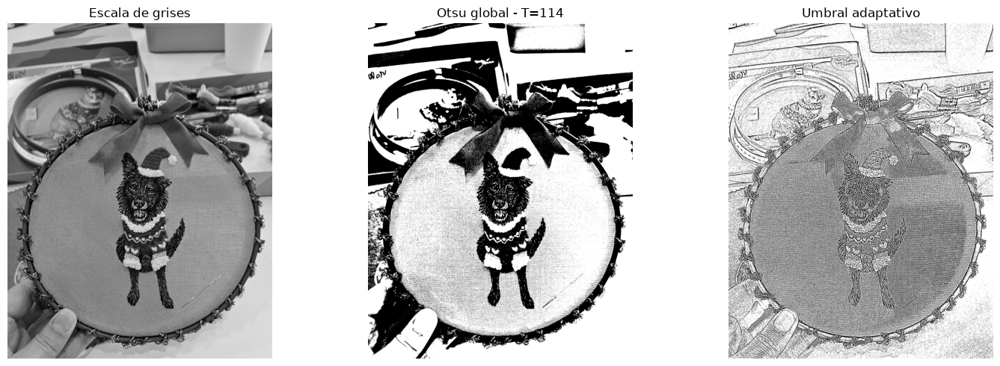

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(imagen_gray, cmap="gray")
ax[0].set_title("Escala de grises")

ax[1].imshow(umbral_otsu, cmap="gray")
ax[1].set_title(f"Otsu global - T={valor_otsu:.0f}")

ax[2].imshow(umbral_adaptativo, cmap="gray")
ax[2].set_title("Umbral adaptativo")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

Otsu usa un único umbral para toda la imagen, el método adaptativo calcula una decisión a partir del vecindario de cada píxel. Por eso el segundo puede responder mejor a iluminación no uniforme, aunque también puede convertir texturas

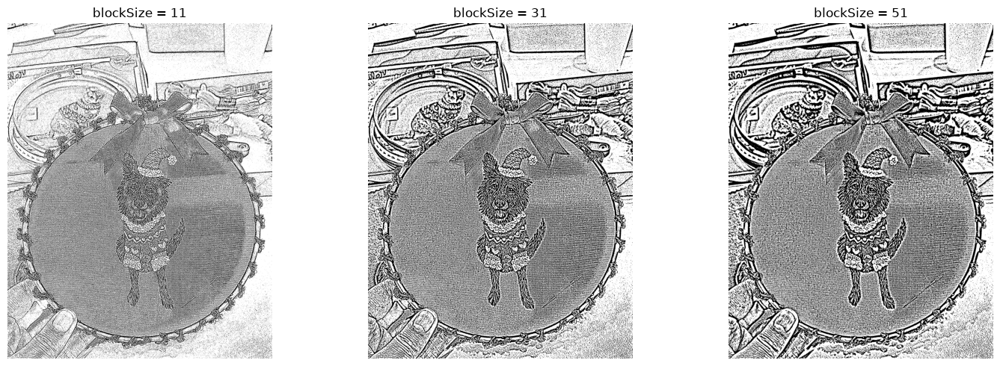

In [30]:
adaptativo_11 = cv2.adaptiveThreshold(gris_suave, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
adaptativo_31 = cv2.adaptiveThreshold(gris_suave, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 2)
adaptativo_51 = cv2.adaptiveThreshold(gris_suave, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 2)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

resultados = [
    adaptativo_11,
    adaptativo_31,
    adaptativo_51
]

titulos = [
    "blockSize = 11",
    "blockSize = 31",
    "blockSize = 51"
]

for a, img, titulo in zip(ax, resultados, titulos):
    a.imshow(img, cmap="gray")
    a.set_title(titulo)
    a.axis("off")

plt.tight_layout()
plt.show()

Al aumentar `blockSize`, cada píxel se compara con un contexto espacial más amplio. Entonces esto cambia la escala de las variaciones que el método considera relevantes porque valores pequeños siguen detalles locales y valores grandes producen una decisión más global

## Detección de bordes con Canny

In [31]:
bordes_50_100 = cv2.Canny(gris_suave, 50, 100)
bordes_100_200 = cv2.Canny(gris_suave, 100, 200)
bordes_150_250 = cv2.Canny(gris_suave, 150, 250)

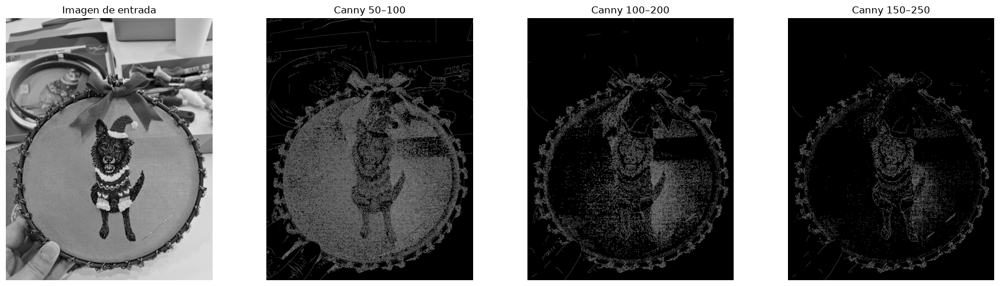

In [32]:
fig, ax = plt.subplots(1, 4, figsize=(18, 5))

imagenes = [
    gris_suave,
    bordes_50_100,
    bordes_100_200,
    bordes_150_250
]

titulos = [
    "Imagen de entrada",
    "Canny 50–100",
    "Canny 100–200",
    "Canny 150–250"
]

for a, img, titulo in zip(ax, imagenes, titulos):
    a.imshow(img, cmap="gray")
    a.set_title(titulo)
    a.axis("off")

plt.tight_layout()
plt.show()

Al pasar de `50–100` a `150–250` se exige un gradiente más fuerte por lo que quedan menos bordes

## Influencia del suavizado sobre los bordes

In [34]:
canny_sin_suavizado = cv2.Canny(imagen_gray, 50, 100)

In [35]:
gris_gauss_3 = cv2.GaussianBlur(imagen_gray, (3, 3), 0)
gris_gauss_9 = cv2.GaussianBlur(imagen_gray, (9, 9), 0)
canny_gauss_3 = cv2.Canny(gris_gauss_3, 50, 100)
canny_gauss_9 = cv2.Canny(gris_gauss_9, 50, 100)

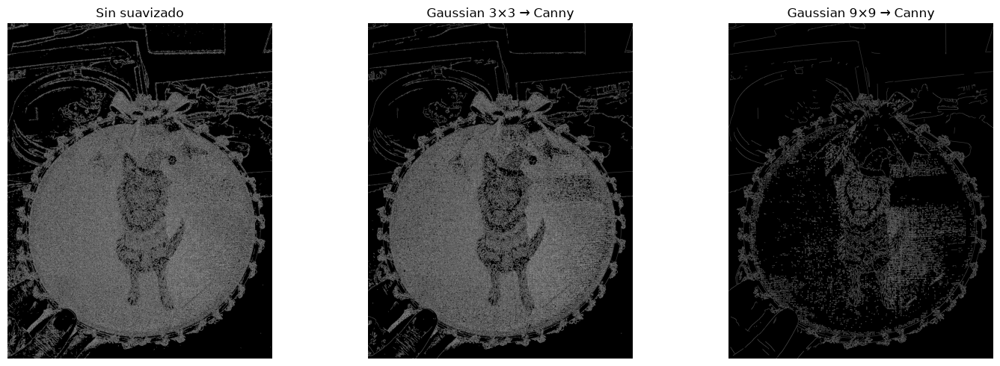

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

imagenes = [
    canny_sin_suavizado,
    canny_gauss_3,
    canny_gauss_9
]

titulos = [
    "Sin suavizado",
    "Gaussian 3×3 → Canny",
    "Gaussian 9×9 → Canny"
]

for a, img, titulo in zip(ax, imagenes, titulos):
    a.imshow(img, cmap="gray")
    a.set_title(titulo)
    a.axis("off")

plt.tight_layout()
plt.show()

## Comparación cuantitativa de bordes

In [37]:
def porcentaje_bordes(imagen_bordes):
    pixeles_borde = np.count_nonzero(imagen_bordes)
    pixeles_totales = imagen_bordes.size

    return (pixeles_borde / pixeles_totales) * 100

In [38]:
p_50_100 = porcentaje_bordes(bordes_50_100)
p_100_200 = porcentaje_bordes(bordes_100_200)
p_150_250 = porcentaje_bordes(bordes_150_250)

print(f"Canny 50–100: {p_50_100:.2f}%")
print(f"Canny 100–200: {p_100_200:.2f}%")
print(f"Canny 150–250: {p_150_250:.2f}%")

Canny 50–100: 14.93%
Canny 100–200: 5.49%
Canny 150–250: 2.61%


In [39]:
print(
    f"Sin suavizado: "
    f"{porcentaje_bordes(canny_sin_suavizado):.2f}%"
)

print(
    f"Gaussian 3×3: "
    f"{porcentaje_bordes(canny_gauss_3):.2f}%"
)

print(
    f"Gaussian 9×9: "
    f"{porcentaje_bordes(canny_gauss_9):.2f}%"
)

Sin suavizado: 20.19%
Gaussian 3×3: 17.46%
Gaussian 9×9: 4.46%


El porcentaje de bordes funciona aquí como una medida descriptiva de cuánta estructura queda marcada. Una reducción del porcentaje puede significar menos ruido gracias al suavizado, pero también la pérdida de contornos útiles

## Selección de una tarea de visión: segmentación

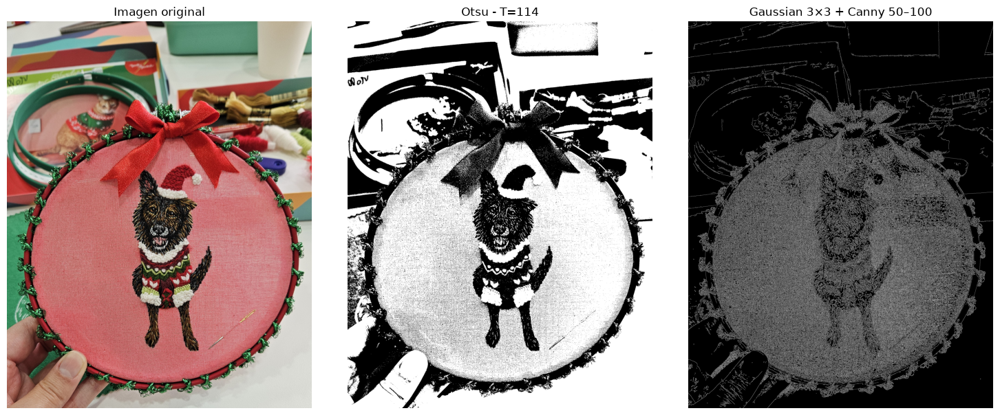

In [41]:
fig, ax = plt.subplots(1, 3, figsize=(15, 6))

ax[0].imshow(imagen_rgb)
ax[0].set_title("Imagen original")

ax[1].imshow(umbral_otsu, cmap="gray")
ax[1].set_title(f"Otsu - T={valor_otsu:.0f}")

ax[2].imshow(canny_gauss_3, cmap="gray")
ax[2].set_title("Gaussian 3×3 + Canny 50–100")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

Otsu produce una máscara de regiones y Canny produce contornos, para segmentar el objeto completo se necesita una representación binaria de áreas mientras que los bordes pueden servir como información de su estructura

## Pipeline propuesto

In [43]:
def preprocesar_segmentacion(
    imagen_bgr,
    x1,
    y1,
    x2,
    y2,
    ancho_salida=400
):
    # 1. Conservar la entrada
    trabajo = imagen_bgr.copy()

    # 2. Región de interés
    roi_bgr = trabajo[y1:y2, x1:x2]

    # 3. Escala de grises
    gris_roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)

    # 4. Redimensionamiento conservando proporción
    escala = ancho_salida / gris_roi.shape[1]
    alto_salida = int(gris_roi.shape[0] * escala)

    gris_resize = cv2.resize(gris_roi, (ancho_salida, alto_salida), interpolation=cv2.INTER_AREA)

    # 5. Suavizado ligero
    gris_suave = cv2.GaussianBlur(gris_resize, (3, 3), 0)

    # 6. Umbral automático
    valor_otsu, mascara = cv2.threshold(gris_suave, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return mascara, valor_otsu

El pipeline reúne decisiones que se probaron por separado. Primero limita el contexto con la ROI, después reduce la dimensionalidad a intensidad, disminuye el tamaño conservando proporción y suaviza ligeramente para evitar que pequeñas variaciones dominen la umbralización. Finalmente, Otsu convierte esa imagen preparada en una máscara binaria y devuelve también el umbral que utilizó

In [44]:
mascara_final, otsu_final = preprocesar_segmentacion(
    imagen_original,
    x1=876,
    y1=1000,
    x2=1546,
    y2=2486,
    ancho_salida=400
)

print("Shape:", mascara_final.shape)
print("dtype:", mascara_final.dtype)
print("Otsu:", otsu_final)
print("Valores presentes:", np.unique(mascara_final))

Shape: (887, 400)
dtype: uint8
Otsu: 95.0
Valores presentes: [  0 255]


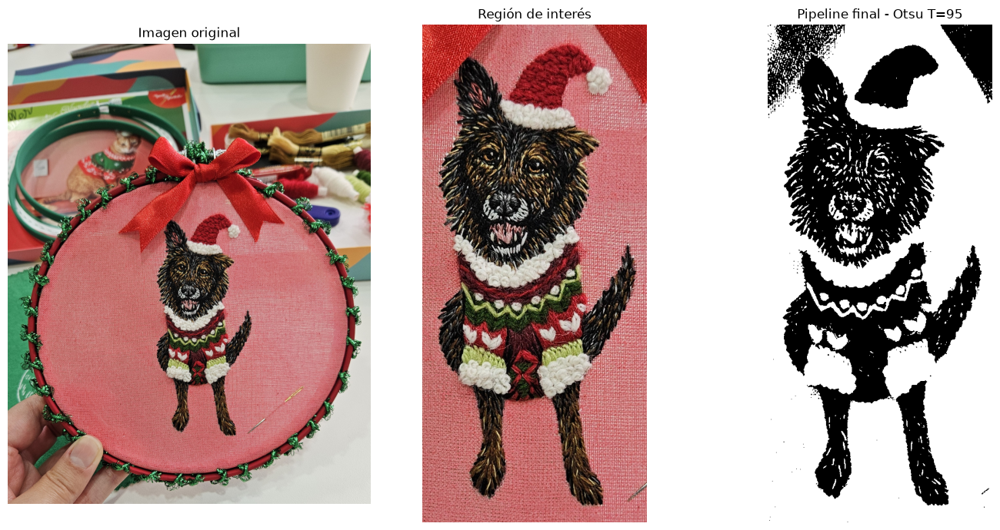

In [45]:
roi_rgb = imagen_rgb[
    1000:2486,
    876:1546
]

fig, ax = plt.subplots(1, 3, figsize=(14, 7))

ax[0].imshow(imagen_rgb)
ax[0].set_title("Imagen original")

ax[1].imshow(roi_rgb)
ax[1].set_title("Región de interés")

ax[2].imshow(mascara_final, cmap="gray")
ax[2].set_title(f"Pipeline final - Otsu T={otsu_final:.0f}")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

## Comparación antes/después del pipeline

In [46]:
print("ORIGINAL")
print("Shape:", imagen_original.shape)
print("dtype:", imagen_original.dtype)
print(
    "Rango:",
    imagen_original.min(),
    imagen_original.max()
)

print("\nSALIDA")
print("Shape:", mascara_final.shape)
print("dtype:", mascara_final.dtype)
print(
    "Valores:",
    np.unique(mascara_final)
)

ORIGINAL
Shape: (2858, 2252, 3)
dtype: uint8
Rango: 0 255

SALIDA
Shape: (887, 400)
dtype: uint8
Valores: [  0 255]


## Conclusiones

Cada transformación produjo una representación diferente de la fotografía original y mostró que una decisión aparentemente sencilla, como cambiar un kernel o un umbral, puede alterar considerablemente el resultado

La conversión entre espacios de color mostró distintos niveles de pérdida y reorganización de la información. RGB mantuvo la información cromática completa, mientras que la escala de grises redujo la imagen de tres canales a uno y eliminó el color, conservando principalmente información de intensidad. HSV, por su parte, permitió separar tono, saturación y brillo

En el redimensionamiento, las diferentes interpolaciones produjeron resultados visualmente similares a la escala utilizada, pero INTER_AREA resultó una elección adecuada para la reducción. La ROI tuvo un efecto más significativo sobre el contenido: permitió pasar de analizar toda la escena a concentrarse en el bordado de la perrita, eliminando gran parte del contexto del taller. La región seleccionada pasó de la imagen original de (2858, 2252, 3) a una ROI de (1486, 670, 3)

Los experimentos de suavizado demostraron que aumentar el tamaño del kernel elimina progresivamente variaciones y detalles finos. Esto se confirmó cuantitativamente al combinar el suavizado con Canny porque sin suavizado se detectó un 20.19 % de píxeles como bordes, con Gaussian 3×3 un 17.46 % y con Gaussian 9×9 solamente un 4.46 %. Por lo tanto un suavizado fuerte reduce considerablemente las transiciones disponibles para las operaciones posteriores y puede eliminar estructuras relevantes junto con el ruido

La umbralización mostró una alta dependencia de los parámetros. Los umbrales manuales de 80, 130 y 180 produjeron separaciones diferentes mientras que Otsu seleccionó automáticamente un valor de 114 sobre la imagen completa. La umbralización adaptativa mostró un comportamiento distinto al utilizar información local porque al aumentar blockSize de 11 a 31 y 51 se hicieron más marcadas diferentes estructuras y texturas de la escena. Esto muestra que un método local puede responder a variaciones de iluminación pero también puede resaltar una cantidad considerable de detalles que no necesariamente son relevantes para la tarea

La detección de bordes fue uno de los experimentos donde el efecto de los parámetros resultó más evidente. Canny 50–100 identificó un 14.93 % de los píxeles como borde 100–200 redujo esta proporción a 5.49 % y 150–250 a 2.61 %. El aumento de los umbrales hace más restrictiva la detección. Sin embargo, estos porcentajes no permiten afirmar por sí solos cuál configuración es mejor porque una mayor cantidad de bordes puede incluir ruido y textura mientras que una configuración demasiado restrictiva puede eliminar contornos relevantes

Para la propuesta final se construyó un pipeline orientado a segmentación mediante la secuencia ROI → escala de grises → resize con INTER_AREA → Gaussian Blur 3×3 → Otsu. Después de estas transformaciones Otsu seleccionó un umbral de 95diferente del 114 obtenido sobre la imagen completa

La salida final pasó de una imagen original de (2858, 2252, 3) con tres canales y valores entre 0 y 255 a una máscara de (887, 400) con un único canal y únicamente los valores 0 y 255. La máscara conserva de forma reconocible gran parte de la estructura de la perrita, incluyendo cabeza, cuerpo y patas, pero también muestra las limitaciones de una segmentación basada únicamente en intensidad porque algunas zonas internas del bordado quedan clasificadas junto con el fondo y aparecen regiones externas no deseadas



